In [1]:
import random, math
import numpy as np
import pandas as pd
from scipy.stats import sem
import matplotlib.pyplot as plt


In [2]:
def simulate_reciprocal(team_size, seed):
    """Specialist (parallel M/M/c) network: each worker is fixed to one stage."""
    rng = random.Random(seed)
    worker_stage = [i % STAGES for i in range(team_size)]
    stage_queues = [[] for _ in range(STAGES)]
    for job in range(N_JOBS):
        for stage in range(STAGES):
            stage_queues[stage].append((job, stage))
    token_done = {}
    job_done = [None] * N_JOBS
    workers = []

    for _ in range(team_size):
        intervals = []
        for _ in range(FAULTS_PER_WORKER):
            start = rng.uniform(0, HORIZON - FAULT_DUR)
            intervals.append((start, start + FAULT_DUR))
        workers.append({"remain": 0, "token": None, "faults": intervals})

    for t in range(HORIZON):
        for wid, w in enumerate(workers):
            st = worker_stage[wid]
            if w["remain"] > 0:
                w["remain"] -= 1
                if w["remain"] == 0:
                    job_id, stage_id = w["token"]
                    token_done[(job_id, stage_id)] = t
                    if sum(1 for s in range(STAGES) if (job_id, s) in token_done) == STAGES:
                        job_done[job_id] = t
                    w["token"] = None
            in_fault = any(a <= t < b for a, b in w["faults"])
            if w["remain"] == 0 and not in_fault and stage_queues[st]:
                tok = stage_queues[st].pop(0)
                w["token"] = tok
                w["remain"] = max(1, math.ceil(rng.expovariate(1 / SERVICE_MEAN)))
    finished = [ct for ct in job_done if ct is not None]
    pct_complete = 100 * len(finished) / N_JOBS
    mean_time = np.mean(finished) if finished else np.nan
    return pct_complete, mean_time


def simulate_pooled(team_size, seed):
    """Generalist (shared M/M/c) network: any worker can pull any queued (job, stage)."""
    rng = random.Random(seed)
    waiting = [(j, s) for j in range(N_JOBS) for s in range(STAGES)]
    token_done = {}
    job_done = [None] * N_JOBS
    workers = []
    for _ in range(team_size):
        intervals = []
        for _ in range(FAULTS_PER_WORKER):
            start = rng.uniform(0, HORIZON - FAULT_DUR)
            intervals.append((start, start + FAULT_DUR))
        workers.append({"remain": 0, "token": None, "faults": intervals})
    for t in range(HORIZON):
        for w in workers:
            if w["remain"] > 0:
                w["remain"] -= 1
                if w["remain"] == 0:
                    job_id, stage_id = w["token"]
                    token_done[(job_id, stage_id)] = t
                    if sum(1 for s in range(STAGES) if (job_id, s) in token_done) == STAGES:
                        job_done[job_id] = t
                    w["token"] = None
            in_fault = any(a <= t < b for a, b in w["faults"])
            if w["remain"] == 0 and not in_fault and waiting:
                tok = waiting.pop(0)
                w["token"] = tok
                w["remain"] = max(1, math.ceil(rng.expovariate(1 / SERVICE_MEAN)))
    finished = [ct for ct in job_done if ct is not None]
    pct_complete = 100 * len(finished) / N_JOBS
    mean_time = np.mean(finished) if finished else np.nan
    return pct_complete, mean_time


In [3]:
def plot_team_size_by_tasks_completed(full_team_summary, title):
    agg = (
        full_team_summary
        .groupby(["fault", "condition", "team_size"])["num_tasks_completed"]
        .agg(["mean", sem])
        .reset_index()
        .rename(columns={"mean": "avg_completed", "sem": "sem_completed"})
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    fig.suptitle(title, fontsize=14, weight="bold", y=1.02)

    palette = {"pooled": "#1f77b4", "reciprocal": "#ff7f0e"}

    for ax, fault_state in zip(axes, [0, 1]):
        sub_fault = agg[agg["fault"] == fault_state]
        for network, color in palette.items():
            sub = sub_fault[sub_fault["condition"] == network].sort_values("team_size")
            x = sub["team_size"].values
            y = sub["avg_completed"].values
            e = sub["sem_completed"].values

            ax.plot(x, y,
                    marker="o",
                    markersize=6,
                    linewidth=2,
                    label=network.capitalize(),
                    color=color)
            # shaded CI
            ax.fill_between(x, y - e, y + e,
                            alpha=0.2,
                            color=color,
                            linewidth=0)

        ax.set_title("Faults" if fault_state == 1 else "No Faults",
                     fontsize=12, weight="semibold")
        ax.set_xlabel("Team size (members)")
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    axes[0].set_ylabel("% Tasks completed")
    axes[0].set_ylim(0, full_team_summary["num_tasks_completed"].max() * 1.1)

    axes[1].legend_.remove() if axes[1].legend_ else None

    handles, labels = axes[0].get_legend_handles_labels()

    # create a single legend for the whole figure
    fig.legend(
        handles=handles,
        labels=labels,
        title="Network",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=2,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

    print(agg.to_string())


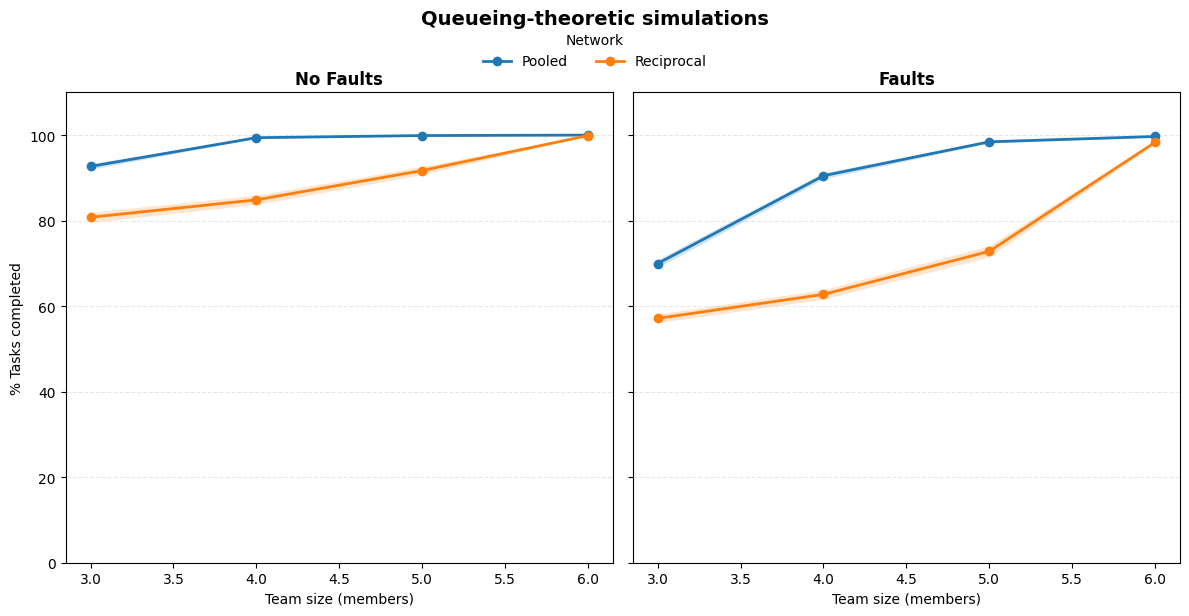

    fault   condition  team_size  avg_completed  sem_completed
0       0      pooled          3      92.678571       0.678269
1       0      pooled          4      99.392857       0.158329
2       0      pooled          5      99.892857       0.061547
3       0      pooled          6     100.000000       0.000000
4       0  reciprocal          3      80.785714       1.192211
5       0  reciprocal          4      84.857143       1.084285
6       0  reciprocal          5      91.714286       0.950579
7       0  reciprocal          6      99.892857       0.079699
8       1      pooled          3      69.964286       0.942259
9       1      pooled          4      90.500000       0.698149
10      1      pooled          5      98.428571       0.282647
11      1      pooled          6      99.678571       0.104967
12      1  reciprocal          3      57.142857       0.998666
13      1  reciprocal          4      62.750000       1.116115
14      1  reciprocal          5      72.821429       1

In [4]:
TEAM_SIZES = [3, 4, 5, 6]
N_JOBS = 14
STAGES = 3
HORIZON = 300       # 5-minute task period, matching the human experiment
SERVICE_MEAN = 20.0
FAULT_DUR = 60
REPS = 200

def simulate_and_record(fault_counts):
    rows = []
    for faults in fault_counts:
        global FAULTS_PER_WORKER
        FAULTS_PER_WORKER = faults
        for size in TEAM_SIZES:
            for condition, sim_fn in [("pooled", simulate_pooled),
                                      ("reciprocal", simulate_reciprocal)]:
                for rep in range(REPS):
                    pct, _ = sim_fn(size, seed=10000 * faults + rep)
                    rows.append({
                        "fault": int(faults > 0),
                        "condition": condition,
                        "team_size": size,
                        "num_tasks_completed": pct
                    })
    return pd.DataFrame(rows)

# Figure 2 (bottom panels): queueing-theoretic simulations, 0 vs. 2 faults per worker
full_team_summary = simulate_and_record([0, 2])

plot_team_size_by_tasks_completed(
    full_team_summary,
    "Queueing-theoretic simulations"
)
